# 3. Passive cable analysis

How does a signal degrade as it travels through this morphology? You can answer
that **without a simulator** — `pynetrees.electrotonics` solves the passive cable
equations directly with sparse linear algebra.

(For active conductances and spiking, see
[`04_neuron_simulation.ipynb`](04_neuron_simulation.ipynb).)

In [1]:
import numpy as np
import pynetrees as pt

tree = pt.repair_tree(pt.sample_tree())

# Physical constants. These are modelling choices with no universal default --
# every function here raises a clear error if they're unset, rather than
# silently assuming a value and returning plausible-looking nonsense.
tree.Ri = 100.0        # axial resistivity      [Ohm*cm]
tree.Gm = 1 / 2500.0   # membrane conductance   [S/cm^2]
tree.Cm = 1.0          # membrane capacitance   [uF/cm^2]

try:
    pt.M_tree(pt.sample_tree())        # a tree with none of them set
except ValueError as e:
    print("as expected:", e)

## Local cable properties

The **length constant** λ is the distance over which a steady signal decays to
1/e. **Electrotonic length** is a segment's physical length measured in units of
λ — i.e. how much signal it actually costs to traverse.

In [2]:
lam  = pt.lambda_tree(tree)    # [cm]
elen = pt.elen_tree(tree)      # dimensionless

print(f"length constant : {lam.min()*1e4:7.1f} - {lam.max()*1e4:7.1f} um")
print(f"total electrotonic length from root to furthest tip: "
      f"{pt.Pvec_tree(tree, elen).max():.3f} lambda")
print(f"input conductance if collapsed to a point: {pt.cgin_tree(tree)*1e9:.2f} nS")

length constant :   285.0 -   518.4 um
total electrotonic length from root to furthest tip: 0.418 lambda
input conductance if collapsed to a point: 15.35 nS


## The conductance matrix

`M_tree` builds the sparse conductance matrix of the equivalent electrical
circuit — the object every other function here is built on.

In [3]:
M = pt.M_tree(tree)
print(f"M: {M.shape}, {M.nnz} non-zeros ({100*M.nnz/M.shape[0]**2:.3f}% dense)")

# sanity check: with the membrane leak removed, the axial part is a graph
# Laplacian, so every row must sum to zero (Kirchhoff's current law)
leakless = pt.repair_tree(pt.sample_tree())
leakless.Ri, leakless.Gm = 100.0, 0.0
print("max |row sum| with Gm=0:", np.abs(pt.M_tree(leakless).toarray().sum(axis=1)).max())

M: (197, 197), 589 non-zeros (1.518% dense)
max |row sum| with Gm=0: 1.7810197761036761e-12


## Voltage attenuation

`sse_tree(tree, I=node)` injects 1 nA at `node` and returns the steady-state
voltage **everywhere**. This is the direct measure of how well a synapse at one
location is "heard" at another.

In [4]:
plen = pt.Pvec_tree(tree, pt.len_tree(tree))
tips = np.flatnonzero(pt.T_tree(tree))
distal = int(tips[np.argmax(plen[tips])])   # furthest tip
root = 0

v_from_root   = pt.sse_tree(tree, I=root)     # inject at soma
v_from_distal = pt.sse_tree(tree, I=distal)   # inject at the distal tip

print(f"inject at root   -> V(root)   = {v_from_root[root]:8.3f} mV")
print(f"                    V(distal) = {v_from_root[distal]:8.3f} mV")
print(f"inject at distal -> V(distal) = {v_from_distal[distal]:8.3f} mV")
print(f"                    V(root)   = {v_from_distal[root]:8.3f} mV")

inject at root   -> V(root)   =   69.753 mV
                    V(distal) =   61.154 mV
inject at distal -> V(distal) =  113.293 mV
                    V(root)   =   61.154 mV


Two things worth noticing:

- **Input resistance is much higher at the thin distal tip** than at the soma —
  the same current produces a far larger local voltage there.
- **The transfer is reciprocal**: distal→root equals root→distal. That's a
  theorem for passive linear cables, and a good correctness check.

In [5]:
print(f"root -> distal : {v_from_root[distal]:.6f} mV")
print(f"distal -> root : {v_from_distal[root]:.6f} mV")
print("reciprocal:", np.isclose(v_from_root[distal], v_from_distal[root]))

root -> distal : 61.154449 mV
distal -> root : 61.154449 mV
reciprocal: True


### Where does the signal actually go?

Colouring the morphology by the voltage from a distal injection shows the
electrotonic structure directly.

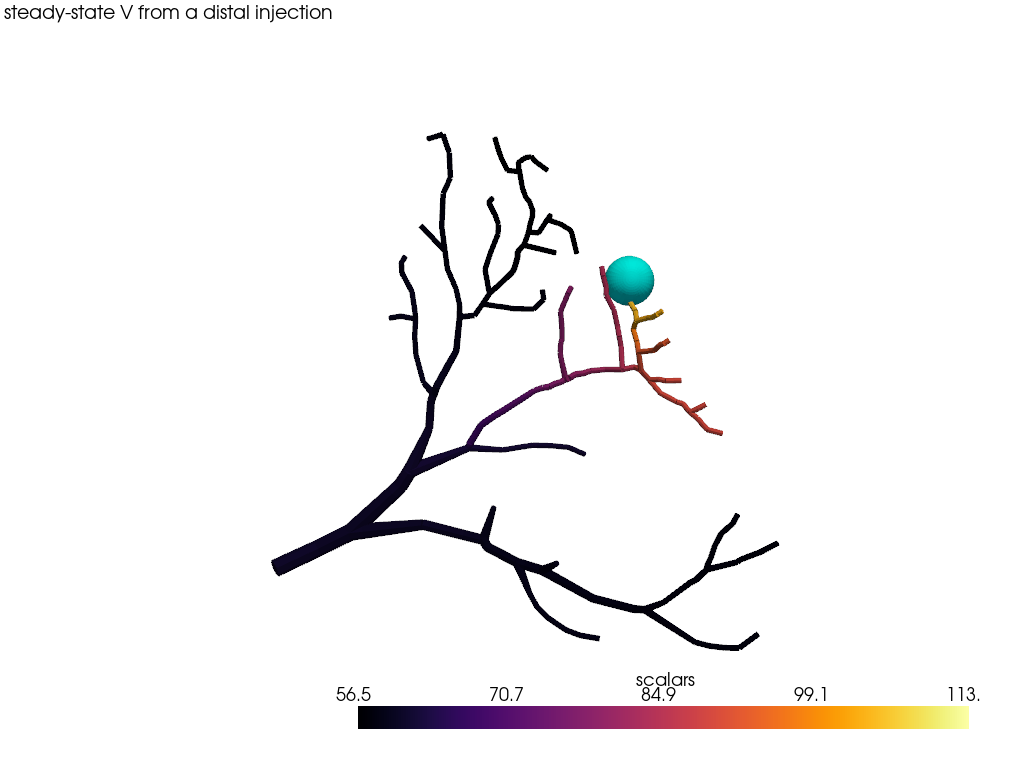

In [6]:
pl = pt.plot_tree(tree, scalars=v_from_distal, cmap="inferno", mode="tube", res=8)
pt.pointer_tree(pl, tree, nodes=[distal], style="sphere", color="cyan", size=6)
pl.add_text("steady-state V from a distal injection", font_size=10)
pl.camera_position = "xy"
pl.screenshot("tut03_attenuation.png")
pl.close()

from IPython.display import Image
Image("tut03_attenuation.png")

### Attenuation vs. distance

Because `sse_tree` returns a full per-node array, plotting attenuation against
path distance is a one-liner.

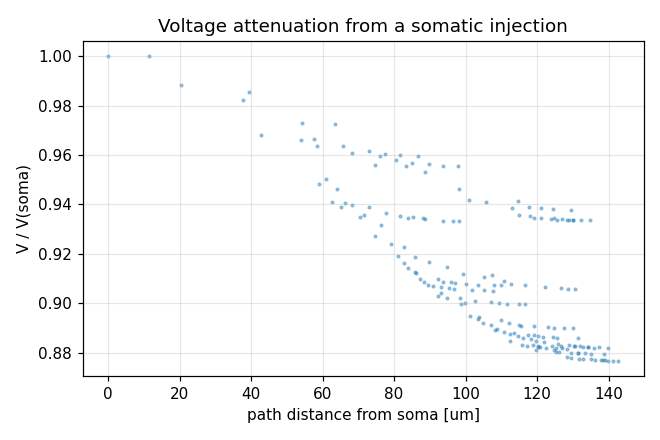

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(plen, v_from_root / v_from_root[root], s=3, alpha=0.4)
ax.set_xlabel("path distance from soma [um]")
ax.set_ylabel("V / V(soma)")
ax.set_title("Voltage attenuation from a somatic injection")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("tut03_attenuation_curve.png", dpi=110)
plt.close(fig)

from IPython.display import Image
Image("tut03_attenuation_curve.png")

## Synaptic input

`syn_tree` solves the steady state with a synaptic **conductance** rather than
an injected current.

One convention to be aware of: everything in this module is expressed as a
**deviation from resting potential**, so rest is 0 and the reversal potentials
`Ee`/`Ei` are driving forces relative to it (defaults: +60 and -20 mV, matching
the MATLAB toolbox). Passing `Ee=0` would mean "no driving force" and correctly
returns a flat zero solution.

In [8]:
v_syn = pt.syn_tree(tree, ge=distal)      # Ee defaults to +60 mV above rest
print("excitatory synapse at the distal tip:")
print(f"  local depolarisation : {v_syn[distal]:.3f} mV")
print(f"  reaching the soma    : {v_syn[root]:.3f} mV")
print(f"  attenuation          : {100*(1 - v_syn[root]/v_syn[distal]):.1f}%")

# The unit conductance used here (1 uS) is very large -- it nearly clamps the
# local membrane to Ee wherever it is placed, so the *local* voltage ends up
# similar at both sites and the informative quantity is how much survives the
# trip to the soma:
v_soma_syn = pt.syn_tree(tree, ge=root)
print()
print(f"same synapse at the soma: local {v_soma_syn[root]:.3f} mV")
lost = 100 * (1 - v_syn[root] / v_soma_syn[root])
print(f"-> a distal synapse delivers {lost:.1f}% less to the soma than a somatic one")

excitatory synapse at the distal tip:
  local depolarisation : 59.475 mV
  reaching the soma    : 32.104 mV
  attenuation          : 46.0%

same synapse at the soma: local 59.152 mV
-> a distal synapse delivers 45.7% less to the soma than a somatic one


## Time-dependent responses

`LIF_tree` steps the full morphology through time (implicit Euler), with an
integrate-and-fire spike mechanism at a chosen node.

passive charging: V(soma) settles at 3.488 mV


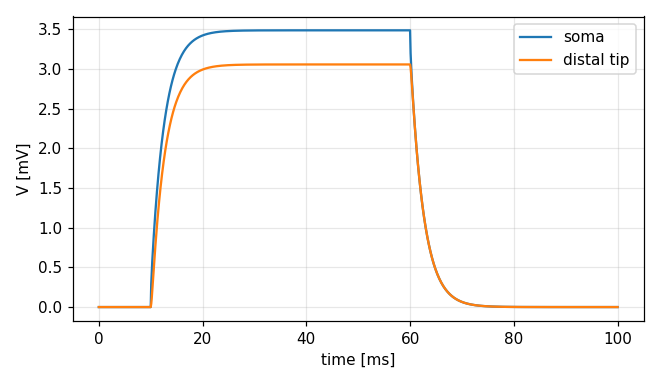

In [9]:
t = np.linspace(0, 100, 1001)          # ms
I = np.zeros((tree.n_nodes, t.size))
I[root, 100:600] = 0.05                # 0.05 nA step into the soma

v, spikes = pt.LIF_tree(tree, time=t, I=I, iroot=root, thr=1e9)  # thr high => passive
print(f"passive charging: V(soma) settles at {v[root, 550]:.3f} mV")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t, v[root], label="soma")
ax.plot(t, v[distal], label="distal tip")
ax.set_xlabel("time [ms]"); ax.set_ylabel("V [mV]")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("tut03_charging.png", dpi=110); plt.close(fig)

from IPython.display import Image
Image("tut03_charging.png")

The distal tip charges more slowly and to a lower level — the morphology acting
as a low-pass filter.

**Next:** [`04_neuron_simulation.ipynb`](04_neuron_simulation.ipynb) — the same
morphology, but with real active conductances in the NEURON simulator.